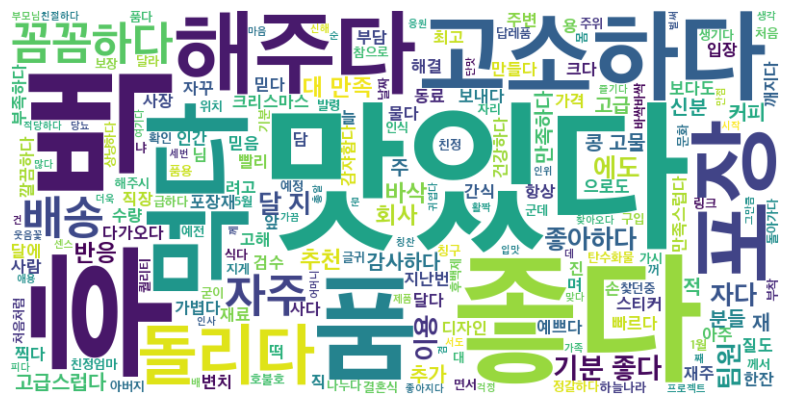

In [20]:
import pandas as pd
from konlpy.tag import Okt
import time
# CSV 파일을 읽어옵니다.
reviews = pd.read_csv('재구매리뷰.csv')

# Okt 객체를 초기화합니다.
okt = Okt()

time.sleep(1)
reviews = reviews.dropna()

review_texts = reviews['Review']

# 각 리뷰에 대해 형태소 분석을 수행하고, 결과를 하나의 리스트로 합칩니다.
all_words = []

# okt()로 형태소 분석
for review in review_texts:
    morphs = okt.morphs(review, stem=True)
    all_words.extend(morphs)


time.sleep(3)
# Stopwords 파일 경로
file_path = '/Users/kang_hiee/Documents/GitHub/ubion/python/최종프로젝트/키워드분석/서브키워드/stopwords.txt'

# 파일을 cp949 인코딩으로 읽기
with open(file_path, 'r', encoding='cp949') as file:
    stopwords = file.read().split(',')

time.sleep(2)
add_stopwords = ['는','다','이','가','더','잘','은','안','ㅎ','맛','거','개','서','만','한','고',
                 '걸','게','곳','중','라','분','수','전','못','두','ㅠ','날','굿','면','해',
                 '꼭','인','씩','번','점','시','말','내','듯','도','호두','강정','호두강정','선물','답례','구매','주문','헷',
                 '엔','에서도']
stopwords.extend(add_stopwords)
time.sleep(2)
# 리뷰 텍스트에서 불용어 제거 함수
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

time.sleep(3)

# 리스트 형태의 all_words에서 불용어 제거 수행
cleaned_reviews = [remove_stopwords(text) for text in all_words]

# 결과 출력
cleaned_reviews


cleaned_reviews2 = [item for item in cleaned_reviews if item !='']
cleaned_reviews2



from wordcloud import WordCloud

import matplotlib.pyplot as plt
# 형태소 리스트를 텍스트로 변환
text = ' '.join(cleaned_reviews2)

# WordCloud 객체 생성
wordcloud = WordCloud(font_path='/content/AppleSDGothicNeoB.ttf',  # 필요 시 폰트 경로 설정
                      width=800,
                      height=400,
                      background_color='white').generate(text)

time.sleep(3)
# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축 제거
plt.show()


In [21]:
from collections import Counter
# 워드클라우드에서 단어와 빈도수 추출
word_freq = wordcloud.process_text(text)
word_freq_counter = Counter(word_freq)

#단어 추출
total_words = word_freq_counter.most_common()

#데이터프레임으로 변환
df_top_words = pd.DataFrame(total_words, columns=['Word', 'Frequency'])

# 결과 출력
print(df_top_words)

# csv저장
df_top_words.to_csv('review_frequecy.csv', index=False)


    Word  Frequency
0    맛있다         20
1    후 백         19
2     좋다         15
3      품         10
4     먹다          9
..   ...        ...
205  올리다          1
206   하객          1
207    햇          1
208   뿌듯          1
209   번창          1

[210 rows x 2 columns]


In [22]:
df_top_words
# 맛 포장 배송에 대한 만족하는 리뷰가 주로 구성

,Word,Frequency
0,맛있다,20
1,후 백,19
2,좋다,15
3,품,10
4,먹다,9
...,...,...
205,올리다,1
206,하객,1
207,햇,1
208,뿌듯,1


In [23]:
cleaned_df = pd.DataFrame(cleaned_reviews2, columns=['word'])

In [24]:
cleaned_df.to_excel('워드클라우드생성용.xlsx')

In [25]:
cleaned_df[:50]

,word
0,결혼식
1,직장
2,동료
3,품용
4,포장
5,깔끔하다
6,좋다
7,예전
8,떡
9,돌리다
